# Balance Sheet Summary

Use this notebook to inspect the latest balance sheet and recent balance-sheet history for a public company.

What you can change:

- `ticker`: one Yahoo Finance symbol, for example `AAPL`, `MSFT`, or `NVDA`.
- `years`: number of recent annual periods to show in the history table and chart.

The latest snapshot uses the newest annual balance sheet available from yfinance. The history table and chart use annual time-series values.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next(path for path in candidates if (path / "utils.py").exists())

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from quick_views.balance_sheet_summary import build_balance_sheet_snapshot, plot_balance_sheet

def format_money(value):
    """Format large balance-sheet values without requiring pandas Styler/jinja2."""
    if pd.isna(value):
        return ""
    return f"{value:,.0f}"

def format_ratio(value):
    """Format ratio values without requiring pandas Styler/jinja2."""
    if pd.isna(value):
        return ""
    return f"{value:.4f}"

print(f"Project root: {project_root}")

Project root: C:\Users\lnazareno\OneDrive - European Banking Authority\Documents\Projects\financial_analysis


## Inputs

Edit this cell and rerun the cells below.

In [2]:
ticker = "AAPL"
years = 4

## Latest Snapshot And Ratios

- `Current Ratio`: current assets divided by current liabilities.
- `Debt To Equity`: total debt divided by stockholders equity.
- `Liabilities To Assets`: total liabilities divided by total assets.
- `Cash To Assets`: cash and short-term investments divided by total assets.

In [3]:
snapshot, ratios, history = build_balance_sheet_snapshot(ticker)

snapshot_display = snapshot.copy()
snapshot_display["value"] = snapshot_display["value"].map(format_money)

ratios_display = ratios.copy()
ratios_display["value"] = ratios_display["value"].map(format_ratio)

display(snapshot_display)
display(ratios_display)

,metric,value
0,Cash And Short Term Investments,"54,697,000,000"
1,Receivables,"72,957,000,000"
2,Inventory,"5,718,000,000"
3,Current Assets,"147,957,000,000"
4,Total Assets,"359,241,000,000"
5,Current Liabilities,"165,631,000,000"
6,Total Debt,"98,657,000,000"
7,Total Liabilities,"285,508,000,000"
8,Stockholders Equity,"73,733,000,000"
9,Retained Earnings,"-14,264,000,000"


,metric,value
0,Current Ratio,0.8933
1,Debt To Equity,1.3380
2,Liabilities To Assets,0.7948
3,Cash To Assets,0.1523


## Recent Balance Sheet History

This table shows annual balance-sheet values over time, so you can inspect whether assets, liabilities, equity, debt, cash, and working capital are rising or falling.

In [4]:
history_display = history.tail(years).copy()
for column in history_display.columns:
    history_display[column] = history_display[column].map(format_money)

display(history_display)

,Cash And Short Term Investments,Receivables,Inventory,Current Assets,Total Assets,Current Liabilities,Total Debt,Total Liabilities,Stockholders Equity,Retained Earnings,Working Capital
2022-09-30,"48,304,000,000","60,932,000,000","4,946,000,000","135,405,000,000","352,755,000,000","153,982,000,000","132,480,000,000","302,083,000,000","50,672,000,000","-3,068,000,000","-18,577,000,000"
2023-09-30,"61,555,000,000","60,985,000,000","6,331,000,000","143,566,000,000","352,583,000,000","145,308,000,000","111,088,000,000","290,437,000,000","62,146,000,000","-214,000,000","-1,742,000,000"
2024-09-30,"65,171,000,000","66,243,000,000","7,286,000,000","152,987,000,000","364,980,000,000","176,392,000,000","106,629,000,000","308,030,000,000","56,950,000,000","-19,154,000,000","-23,405,000,000"
2025-09-30,"54,697,000,000","72,957,000,000","5,718,000,000","147,957,000,000","359,241,000,000","165,631,000,000","98,657,000,000","285,508,000,000","73,733,000,000","-14,264,000,000","-17,674,000,000"


## Chart

The first panel shows the broad accounting structure. The second panel focuses on short-term liquidity.

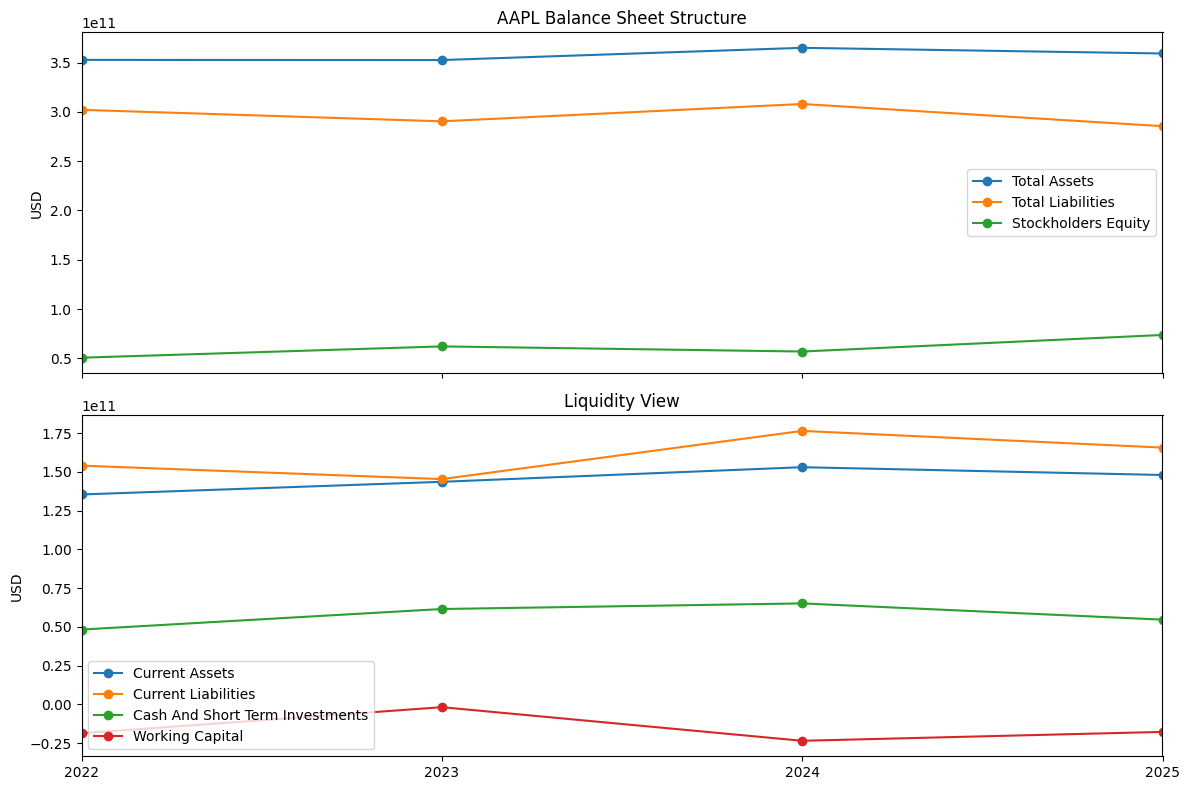

In [5]:
plot_balance_sheet(ticker, history, years)